<a href="https://colab.research.google.com/github/purnimamarasinghe2005-lgtm/BI-and-Data-Mining/blob/main/Business_Intelligence_and_Data_Mining_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Early Readmission of Diabetic Patients: A Business Intelligence Analysis of 130 US Hospitals (1999–2008)

**Module:** Business Intelligence and Data Mining (UFCFMM)  
**Assessment:** Task 2 – Group Project Portfolio  
**Datasets:** **[diabetic_data.csv](https://drive.google.com/file/d/19ZaXM0NpKTD1bQaxtgKqyZR28tH6wRcq/view?usp=drive_link)** and **[IDS_mapping.csv](https://drive.google.com/file/d/1J3bVU-mJaJas84V4LqSuFhhBI21U9_NY/view?usp=drive_link)**


This notebook studies whether hospital encounter data can help identify diabetic patients who are likely to be readmitted within 30 days. Readmission matters from a business perspective because it affects cost, bed capacity, and quality of care. The notebook follows the full business intelligence lifecycle required in the brief: problem definition, dataset justification, preprocessing, exploratory analysis, modelling, evaluation, recommendations, and ethical reflection. The dataset is associated with the study by Strack *et al.* (2014), which supports its academic relevance.




### Background of Diabetic Readmission Problem
Hospital readmission within 30 days is a significant issue in healthcare systems, particularly for patients with chronic conditions such as diabetes. These patients are more likely to experience complications, poor disease management, and comorbidities, which increase the likelihood of repeated hospitalisations. High readmission rates often indicate gaps in treatment effectiveness, discharge planning, or follow-up care.

### Business Importance
From a business perspective, high readmission rates increase operational costs, reduce hospital capacity, and negatively impact performance metrics. Hospitals may face financial penalties from regulators and insurance providers, and readmission rates are often used as indicators of service quality and efficiency.

### Project Objectives
This project aims to develop a predictive model to identify diabetic patients at risk of 30-day readmission. The objectives are to analyse key factors influencing readmission, apply machine learning techniques, generate actionable insights, and evaluate ethical and practical implications.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
from math import pi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from plotly import graph_objects as go

# ==========================================
# [1] Import Libraries
# ==========================================

## Dataset Description

### Source of Dataset
The dataset is obtained from the UCI Machine Learning Repository and contains over 100,000 hospital encounters from multiple US hospitals between 1999 and 2008.

### Key Attributes
The dataset includes:
- Demographic variables (age, gender, race)
- Clinical variables (diagnoses, lab results, medications)
- Hospital utilisation data (inpatient, outpatient, emergency visits)
- Administrative data (admission type, discharge details)

These attributes provide a comprehensive view of patient health and hospital interactions.

### Target Variable Definition
The original readmission variable contains three categories: `<30`, `>30`, and `NO`. This is transformed into a binary variable:
- 1: readmitted within 30 days  
- 0: not readmitted within 30 days  

This simplifies modelling and aligns with the objective of identifying high-risk patients.

In [ ]:
# ==========================================
# #2 LOAD DATASETS (FIX ORDER)
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/diabetic_data.csv")
ids_map = pd.read_csv("/content/IDS_mapping.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##[3] DATA CLEANING & FEATURE ENGINEERING

### [3.1] Data Cleaning
Missing values represented by “?” are converted to NaN for consistency. Several features are removed due to irrelevance or high missingness:
- encounter_id and patient_nbr (identifiers)
- weight (high missing values)
- payer_code and medical_specialty (incomplete and less relevant)

These steps reduce noise and improve data quality.

In [ ]:
#3.1
df.replace('?', np.nan, inplace=True)

df.drop([
    'encounter_id','patient_nbr','weight',
    'payer_code','medical_specialty'
], axis=1, inplace=True)

df['readmitted_binary'] = df['readmitted'].apply(lambda x: 1 if x == "<30" else 0)
df.drop('readmitted', axis=1, inplace=True)

### [3.2] Feature Engineering
Key transformations include:
- Converting age groups into numerical values (age_num)
- Binary encoding for variables such as medication change and diabetes medication usage
- Ordinal encoding for clinical variables such as insulin dosage, A1C results, and glucose levels
- Grouping diagnosis codes into broader categories to reduce dimensionality

These transformations improve model compatibility and interpretability.

In [ ]:
#3.2
age_map = {
    "[0-10)":5,"[10-20)":15,"[20-30)":25,"[30-40)":35,"[40-50)":45,
    "[50-60)":55,"[60-70)":65,"[70-80)":75,"[80-90)":85,"[90-100)":95
}
df["age_num"] = df["age"].map(age_map)

df["change_bin"] = df["change"].replace({"Ch":1,"No":0})
df["diabetesMed_bin"] = df["diabetesMed"].replace({"Yes":1,"No":0})

A1C_map = {"Norm":0,">7":1,">8":2,"None":np.nan}
glu_map = {"Norm":0,">200":1,">300":2,"None":np.nan}
insulin_map = {"No":0,"Steady":1,"Up":2,"Down":3}

df["A1Cresult_bin"] = df["A1Cresult"].map(A1C_map)
df["max_glu_serum_bin"] = df["max_glu_serum"].map(glu_map)
df["insulin_bin"] = df["insulin"].map(insulin_map)

df["diag_1_group"] = df["diag_1"].astype(str).str[0]

/tmp/ipykernel_9916/3486442098.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["change_bin"] = df["change"].replace({"Ch":1,"No":0})
/tmp/ipykernel_9916/3486442098.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["diabetesMed_bin"] = df["diabetesMed"].replace({"Yes":1,"No":0})


### [3.3] Final Dataset Overview
The final dataset consists of structured numerical and encoded categorical variables. Data types are consistent, and summary statistics confirm the distribution and scale of key features.

## Exploratory Data Analysis (EDA)

EDA is conducted to identify patterns and relationships between patient characteristics and readmission risk.

In [ ]:
#3.3
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 52 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   race                      99493 non-null   object 
 1   gender                    101766 non-null  object 
 2   age                       101766 non-null  object 
 3   admission_type_id         101766 non-null  int64  
 4   discharge_disposition_id  101766 non-null  int64  
 5   admission_source_id       101766 non-null  int64  
 6   time_in_hospital          101766 non-null  int64  
 7   num_lab_procedures        101766 non-null  int64  
 8   num_procedures            101766 non-null  int64  
 9   num_medications           101766 non-null  int64  
 10  number_outpatient         101766 non-null  int64  
 11  number_emergency          101766 non-null  int64  
 12  number_inpatient          101766 non-null  int64  
 13  diag_1                    101745 non-null  o

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted_binary,age_num,change_bin,diabetesMed_bin,A1Cresult_bin,max_glu_serum_bin,insulin_bin
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,17018.000000,5346.000000,101766.000000
mean,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607,0.111599,65.967022,0.461952,0.770031,1.189564,0.750655,0.885708
std,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600,0.314874,15.940838,0.498553,0.420815,0.860297,0.812510,1.021758
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,0.000000,55.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,0.000000,65.000000,0.000000,1.000000,1.000000,1.000000,1.000000
75%,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000,0.000000,75.000000,1.000000,1.000000,2.000000,1.000000,1.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000,1.000000,95.000000,1.000000,1.000000,2.000000,2.000000,3.000000


### [4.1] Target Variable Distribution
The dataset shows class imbalance, with fewer patients readmitted within 30 days. This requires careful evaluation using metrics beyond accuracy.

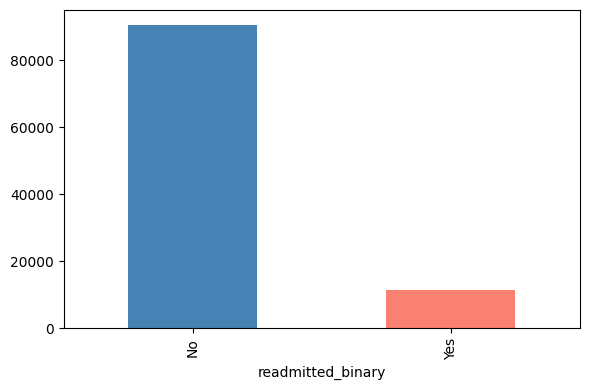

In [ ]:
#4.1
plt.figure(figsize=(6,4))
df["readmitted_binary"].value_counts().plot(kind="bar", color=["steelblue","salmon"])
plt.xticks([0,1],["No","Yes"])
plt.tight_layout()
plt.show()

### [4.2] Demographic Analysis
Older patients show higher readmission rates, suggesting increased vulnerability and need for additional care.

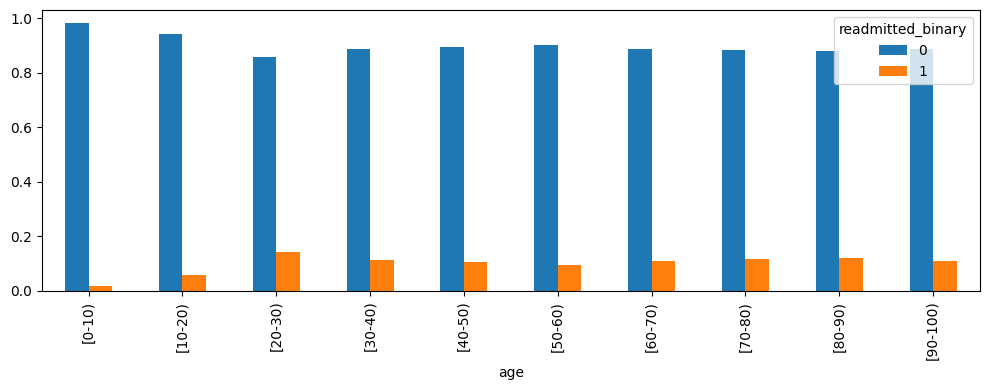

In [ ]:
#4.2
age_order = ["[0-10)","[10-20)","[20-30)","[30-40)","[40-50)",
             "[50-60)","[60-70)","[70-80)","[80-90)","[90-100)"]

age_tab = (
    pd.crosstab(df["age"], df["readmitted_binary"], normalize="index")
    .reindex(age_order)
)
age_tab.plot(kind="bar", figsize=(10,4))
plt.tight_layout()
plt.show()

### [4.3] Hospital Factors
Admission type, discharge disposition, and admission source influence readmission. Certain discharge types are associated with higher risk.

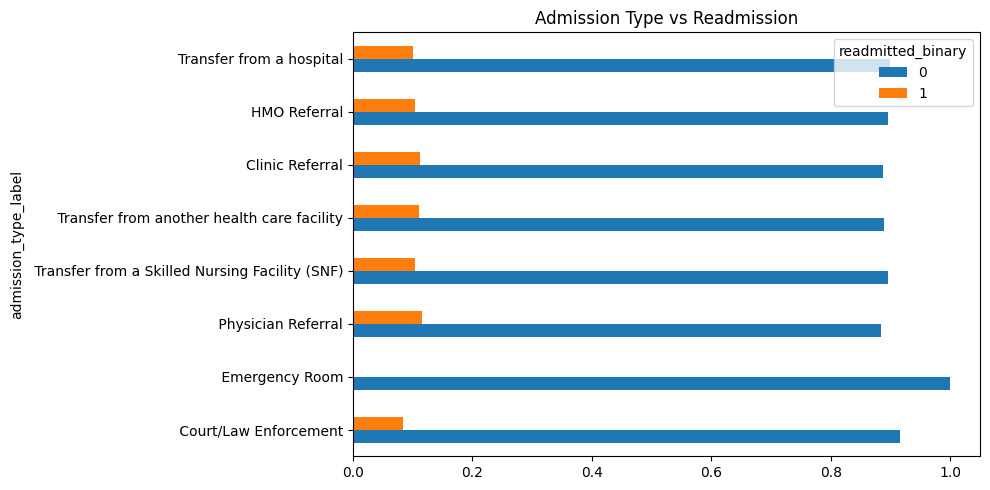

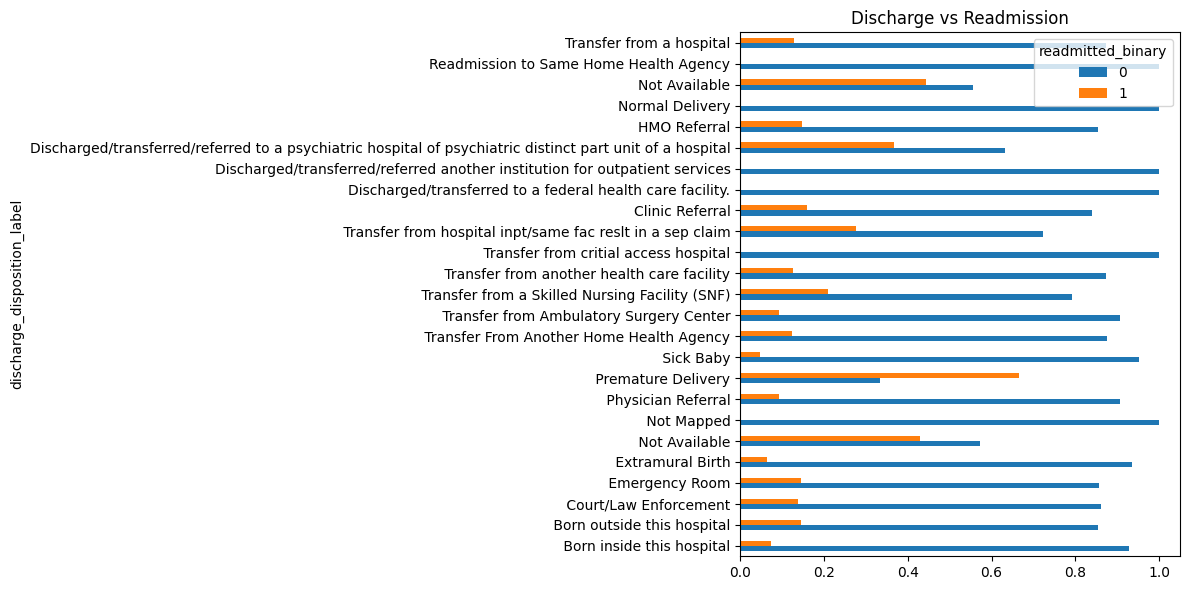

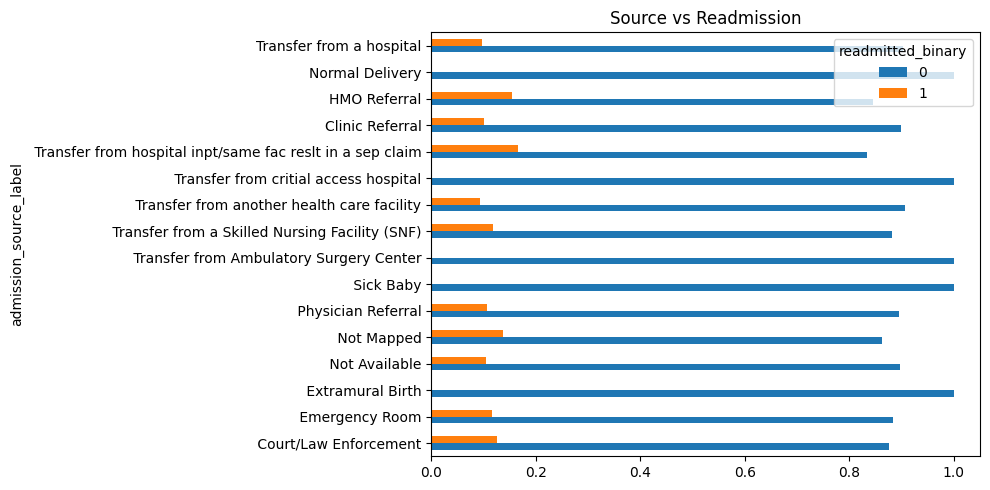

In [ ]:
# ==========================================
# #4.3 FINAL CORRECT VERSION (MULTI-SECTION CSV)
# ==========================================

# Ensure 'admission_type_id' is numeric in ids_map
ids_map['admission_type_id'] = pd.to_numeric(ids_map['admission_type_id'], errors='coerce')

# Split mapping into 3 parts based on ID ranges

# --- Admission Type (1–8) ---
adm_map_df = ids_map[ids_map['admission_type_id'].between(1,8)]
admission_type_map = adm_map_df.set_index('admission_type_id')['description'].to_dict()


# --- Discharge Disposition (1–30) ---
dis_map_df = ids_map[ids_map['admission_type_id'].between(1,30)]
discharge_disposition_map = dis_map_df.set_index('admission_type_id')['description'].to_dict()


# --- Admission Source (1–26) ---
src_map_df = ids_map[ids_map['admission_type_id'].between(1,26)]
admission_source_map = src_map_df.set_index('admission_type_id')['description'].to_dict()


# ==========================================
# APPLY MAPPING
# ==========================================

df["admission_type_label"] = df["admission_type_id"].map(admission_type_map)
df["discharge_disposition_label"] = df["discharge_disposition_id"].map(discharge_disposition_map)
df["admission_source_label"] = df["admission_source_id"].map(admission_source_map)


# ==========================================
# PLOTS
# ==========================================

# Admission Type
pd.crosstab(df["admission_type_label"], df["readmitted_binary"], normalize="index") \
    .plot(kind="barh", figsize=(10,5))
plt.title("Admission Type vs Readmission")
plt.tight_layout()
plt.show()


# Discharge
pd.crosstab(df["discharge_disposition_label"], df["readmitted_binary"], normalize="index") \
    .plot(kind="barh", figsize=(12,6))
plt.title("Discharge vs Readmission")
plt.tight_layout()
plt.show()


# Admission Source
pd.crosstab(df["admission_source_label"], df["readmitted_binary"], normalize="index") \
    .plot(kind="barh", figsize=(10,5))
plt.title("Source vs Readmission")
plt.tight_layout()
plt.show()

### [4.4] Clinical Factors
Diagnosis groups and medication changes are important predictors. Patients with complex conditions or medication adjustments are more likely to be readmitted.


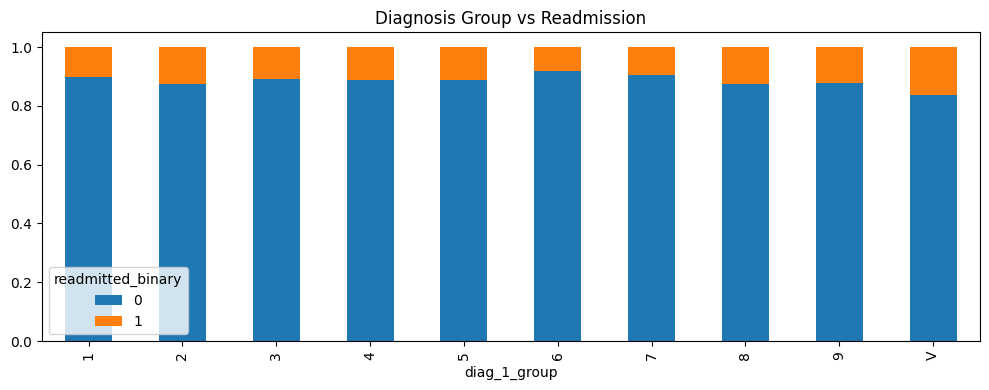

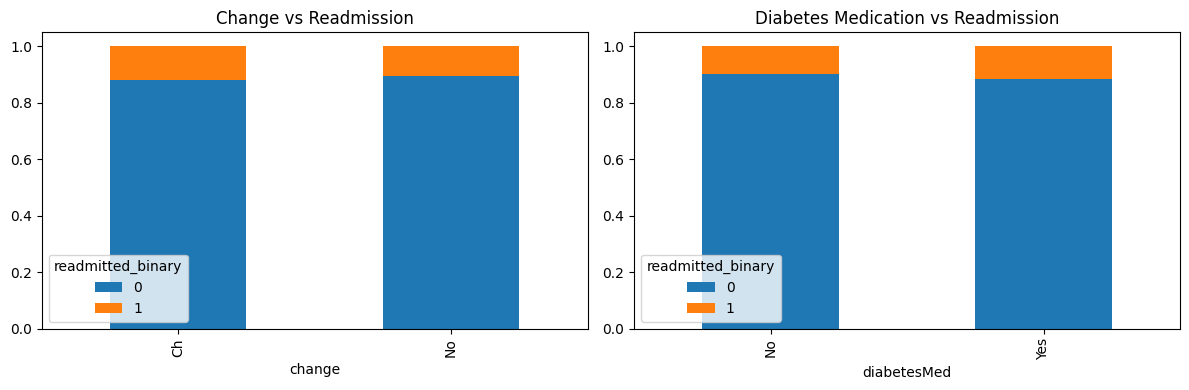

In [ ]:
# ==========================================
# #4.4 Diagnosis + Medication (IMPROVED STYLE)
# ==========================================

top_diag = df["diag_1_group"].value_counts().head(10).index

diag_tab = pd.crosstab(
    df.loc[df["diag_1_group"].isin(top_diag), "diag_1_group"],
    df.loc[df["diag_1_group"].isin(top_diag), "readmitted_binary"],
    normalize="index"
)

diag_tab.plot(kind="bar", stacked=True, figsize=(10,4))
plt.title("Diagnosis Group vs Readmission")
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1,2, figsize=(12,4))

pd.crosstab(df["change"], df["readmitted_binary"], normalize="index") \
    .plot(kind="bar", stacked=True, ax=axes[0])
axes[0].set_title("Change vs Readmission")

pd.crosstab(df["diabetesMed"], df["readmitted_binary"], normalize="index") \
    .plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("Diabetes Medication vs Readmission")

plt.tight_layout()
plt.show()



### [4.5] Feature Distributions
Histograms show that readmitted patients generally have higher values in hospital utilisation metrics.

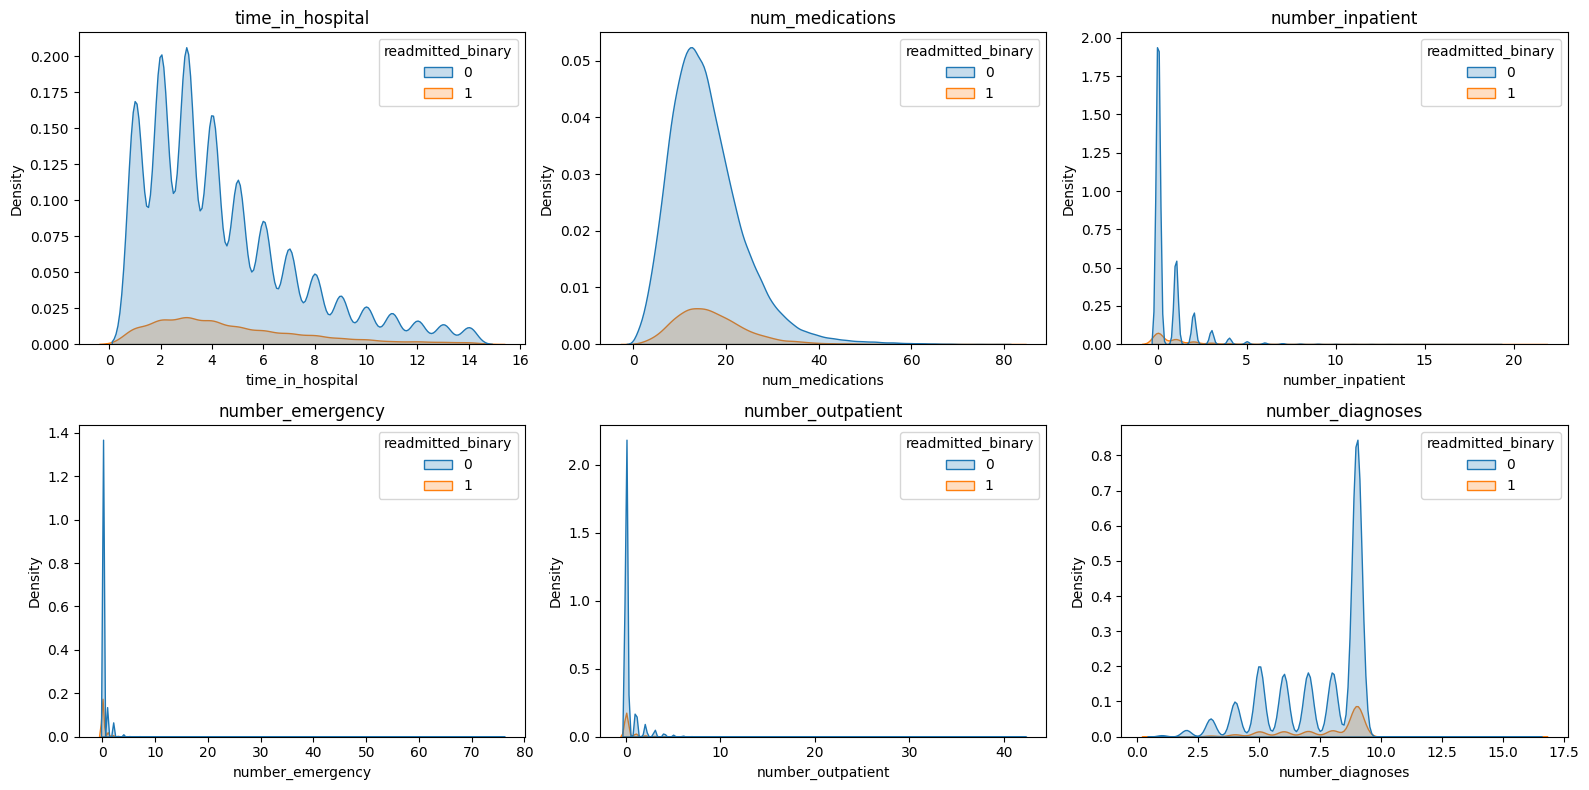

In [ ]:
# ==========================================
# #4.5 Numeric Distribution (BOX + DENSITY)
# ==========================================

features_num = [
    "time_in_hospital",
    "num_medications",
    "number_inpatient",
    "number_emergency",
    "number_outpatient",
    "number_diagnoses"
]

fig, axes = plt.subplots(2,3, figsize=(16,8))
axes = axes.ravel()

for ax, col in zip(axes, features_num):
    sns.kdeplot(data=df, x=col, hue="readmitted_binary", ax=ax, fill=True)
    ax.set_title(col)

plt.tight_layout()
plt.show()

### [4.6] Boxplot Analysis
Boxplots confirm that variables such as hospital stay duration and number of medications are higher for readmitted patients.

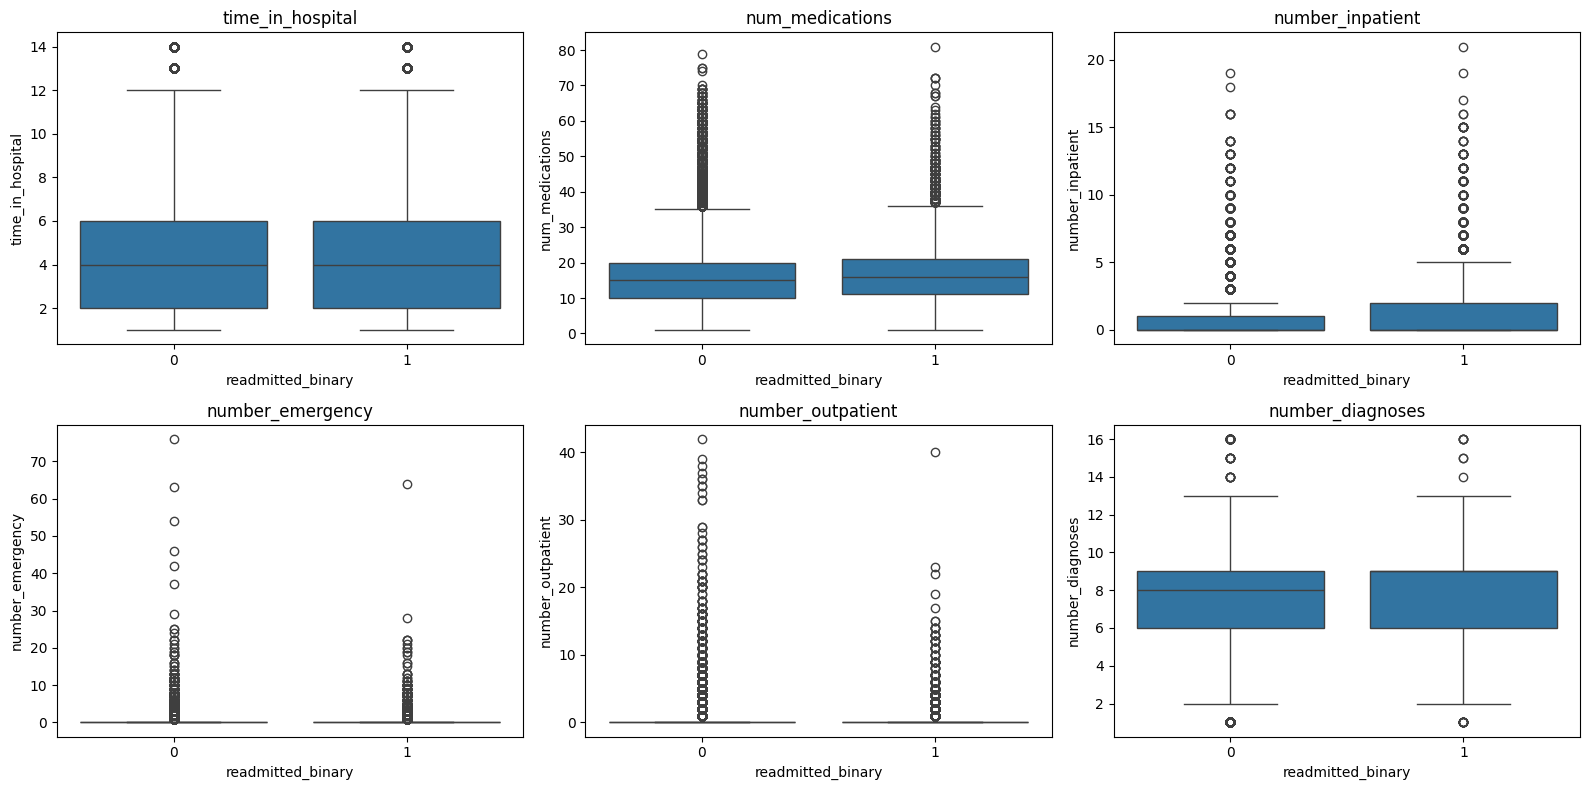

In [ ]:
# ==========================================
# #4.6 (CHANGE → MULTI PANEL CLEAN STYLE)
# ==========================================

features_hist = [
    "time_in_hospital",
    "num_medications",
    "number_inpatient",
    "number_emergency",
    "number_outpatient",
    "number_diagnoses"
]

fig, axes = plt.subplots(2,3, figsize=(16,8))
axes = axes.ravel()

for ax, col in zip(axes, features_hist):
    sns.boxplot(x="readmitted_binary", y=col, data=df, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

### [4.7] Correlation Analysis
Correlation analysis shows that inpatient visits, emergency visits, and number of diagnoses are moderately associated with readmission.

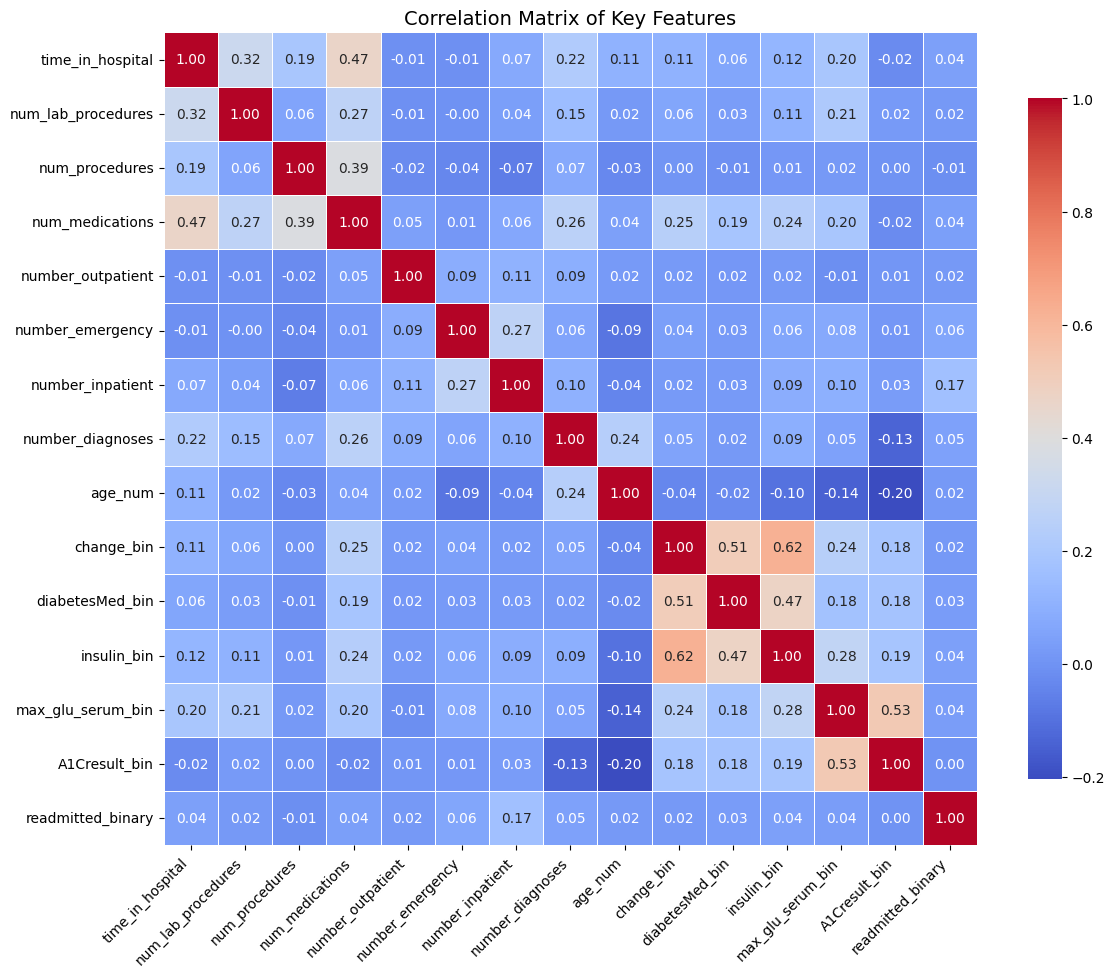

In [ ]:
# ==========================================
# Correlation Heatmap (Clean & Readable)
# ==========================================

# Step 1: Select relevant features for analysis
correlation_columns = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "age_num",
    "change_bin",
    "diabetesMed_bin",
    "insulin_bin",
    "max_glu_serum_bin",
    "A1Cresult_bin",
    "readmitted_binary"
]

# Step 2: Create a subset of the dataset
correlation_data = df[correlation_columns]

# Step 3: Compute correlation matrix
correlation_matrix = correlation_data.corr()

# Step 4: Plot heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,              # Show correlation values
    fmt=".2f",               # Format to 2 decimal places
    cmap="coolwarm",         # Color scheme
    linewidths=0.5,          # Grid lines
    square=True,             # Make cells square
    cbar_kws={"shrink": 0.8} # Adjust color bar size
)

# Step 5: Improve readability
plt.title("Correlation Matrix of Key Features", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Unsupervised Learning: K-Means Clustering

### Justification for K-Means
K-Means clustering is used to identify groups of patients with similar characteristics without predefined labels. This helps uncover hidden patterns and supports patient segmentation for targeted interventions.


### [5.1] Feature Selection
Relevant numerical features with sufficient variation are selected to ensure meaningful clustering.


In [ ]:
# 5.1 Feature Selection based on Correlation

corr_target = correlation_matrix["readmitted_binary"].abs()

effective_features = corr_target[corr_target >= 0.05].index.tolist()

# Remove target variable itself
if "readmitted_binary" in effective_features:
    effective_features.remove("readmitted_binary")

# Select features with more than 2 unique values
km_features = [col for col in effective_features if df[col].nunique() > 2]

### [5.2] Data Scaling
Standardisation is applied to ensure all features contribute equally.

In [ ]:
#5.2
from sklearn.preprocessing import StandardScaler

df_km = df[km_features].dropna() # Drop rows with NaN values for clustering
scaled_km = StandardScaler().fit_transform(df_km)

### [5.3] Elbow Method
The elbow method is used to determine the optimal number of clusters based on within-cluster variance.

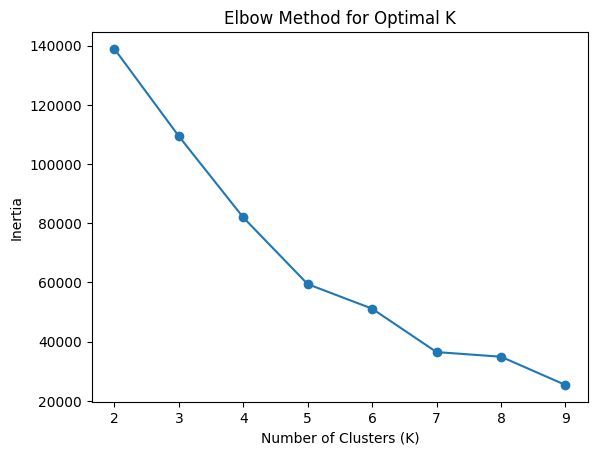

In [ ]:
#5.3
from sklearn.cluster import KMeans

inertia = []
for k in range(2,10):
    inertia.append(KMeans(n_clusters=k, random_state=42).fit(scaled_km).inertia_)

plt.plot(range(2,10), inertia, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

### [5.4] Silhouette Score
Silhouette scores assess cluster quality by measuring separation and cohesion.

In [ ]:
#5.4
from sklearn.metrics import silhouette_score

for k in range(2, 5):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=100)
    labels = kmeans.fit_predict(scaled_km[:15000])  # only first 15k rows
    score = silhouette_score(scaled_km[:15000], labels)
    print(k, score)

2 0.8154734661597053
3 0.8403012118796285
4 0.8422236259503662


### [5.5] PCA for Dimensionality Reduction
PCA reduces dimensionality and enables visualisation of clusters.

In [ ]:
#5.5
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_2d = pca.fit_transform(scaled_km)

### [5.6] Cluster Visualisation
Clusters are visualised in two dimensions, showing clear separation between groups.

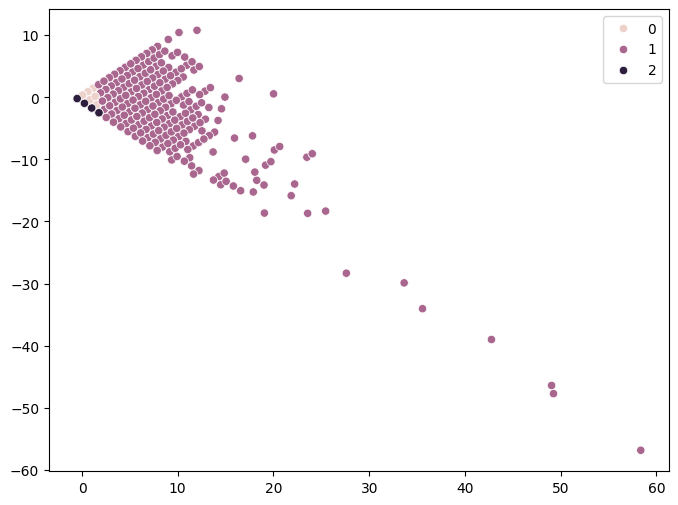

In [ ]:
#5.6
km = KMeans(n_clusters=3, random_state=42)
labels = km.fit_predict(scaled_km)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_2d[:,0], y=pca_2d[:,1], hue=labels)
plt.show()

### [5.7] Cluster Profiling & Insights
Clusters reveal distinct patient segments:
- Low-risk patients with minimal hospital use
- Moderate-risk patients with some complexity
- High-risk patients with frequent visits and multiple conditions

These insights support targeted healthcare strategies.

In [ ]:
#5.7
df.loc[df_km.index, "cluster"] = labels
df.groupby("cluster")[km_features].mean()

,number_emergency,number_inpatient
cluster,,
0.0,0.145696,1.419442
1.0,1.870898,4.308871
2.0,0.082547,0.000000


## Predictive Modelling



In [ ]:
# ==========================================
# [6] Predictive Modelling
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Identify columns to drop from X before encoding
cols_to_drop_from_X = [
    "readmitted_binary", # This is the target variable
    "age", # Using age_num instead
    "change", # Using change_bin instead
    "diabetesMed", # Using diabetesMed_bin instead
    "A1Cresult", # Using A1Cresult_bin instead
    "max_glu_serum", # Using max_glu_serum_bin instead
    "insulin", # Using insulin_bin instead
    "diag_1" # Using diag_1_group instead
]

X = df.drop(cols_to_drop_from_X, axis=1)
y = df["readmitted_binary"]

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include='object').columns

# Apply one-hot encoding
X = pd.get_dummies(X, columns=categorical_cols, dummy_na=False)

# Handle potential missing numerical values (e.g., from A1Cresult_bin or max_glu_serum_bin)
# RandomForest can handle NaNs, but it's often better to explicitly manage them.
# Filling with 0 is a simple approach here; more sophisticated imputation methods could be used.
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### [6.1] Train-Test Split
The dataset is split into training and testing sets using stratification to preserve class distribution.


In [ ]:
# ==========================================
# 6.1 Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (81412, 1691)
Testing set: (20354, 1691)



### [6.2] Logistic Regression (Baseline)
Logistic Regression is used as a baseline model due to its simplicity and interpretability.



In [ ]:
# ==========================================
# 6.2 Logistic Regression (Baseline)
# ==========================================

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### [6.3] Decision Tree
Decision Trees capture non-linear relationships and provide interpretable decision rules.



In [ ]:
# ==========================================
# 6.3 Decision Tree
# ==========================================

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]



### [6.4] Random Forest (Main Model)
Random Forest is selected as the primary model due to its ability to handle complex patterns and reduce overfitting through ensemble learning.

In [ ]:
# ==========================================
# 6.4 Random Forest (Main Model)
# ==========================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

## Model Evaluation


### [7.1] Confusion Matrix Analysis

Confusion matrices are useful because they show the types of prediction errors made by each model. In this project, **false negatives** are especially important because they represent genuinely high-risk patients who were not identified by the model.

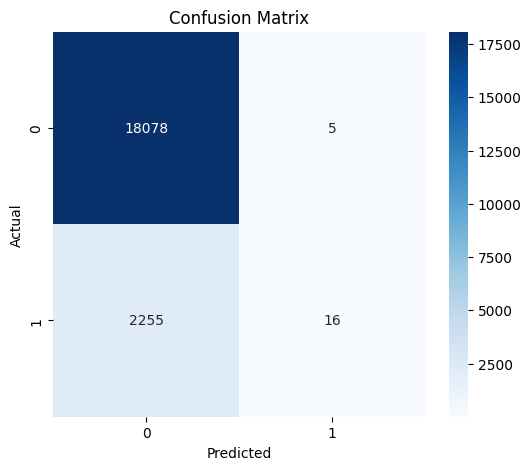

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.76      0.01      0.01      2271

    accuracy                           0.89     20354
   macro avg       0.83      0.50      0.48     20354
weighted avg       0.87      0.89      0.84     20354



In [ ]:
# ==========================================
# [7.1] Confusion Matrix
# ==========================================

from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred))

### [7.2] ROC Curve & AUC
ROC-AUC measures the model’s ability to distinguish between classes; higher values indicate better performance.

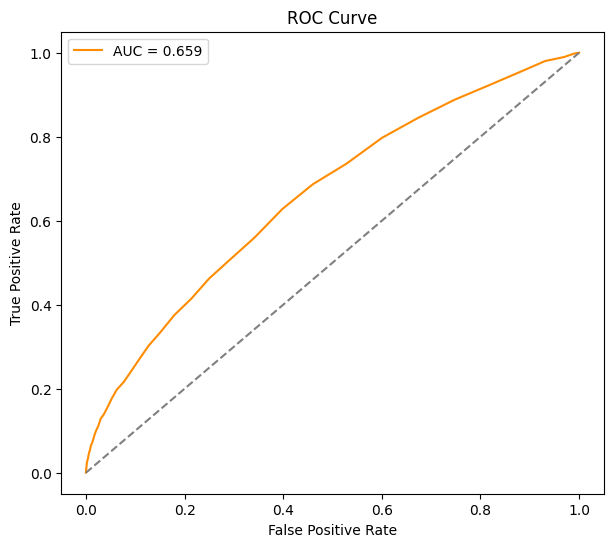

In [ ]:
# ==========================================
# [7.2] ROC Curve & AUC
# ==========================================

from sklearn.metrics import roc_curve, auc

y_proba = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color="darkorange", label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### [7.3] Precision-Recall Curve
This metric is important for imbalanced data, focusing on the model’s ability to correctly identify positive cases.


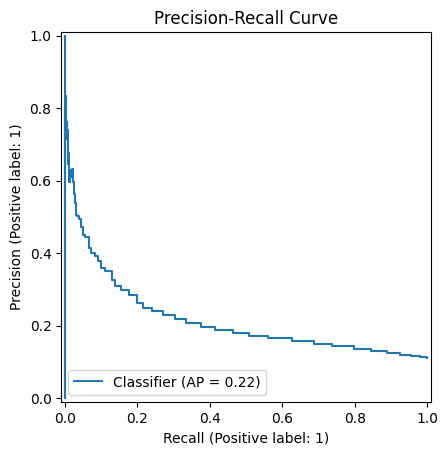

In [ ]:
# ==========================================
# [7.3] Precision-Recall Curve
# ==========================================

from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Precision-Recall Curve")
plt.show()

### [7.4] Feature Importance
Feature importance identifies key predictors, supporting interpretability and decision-making.

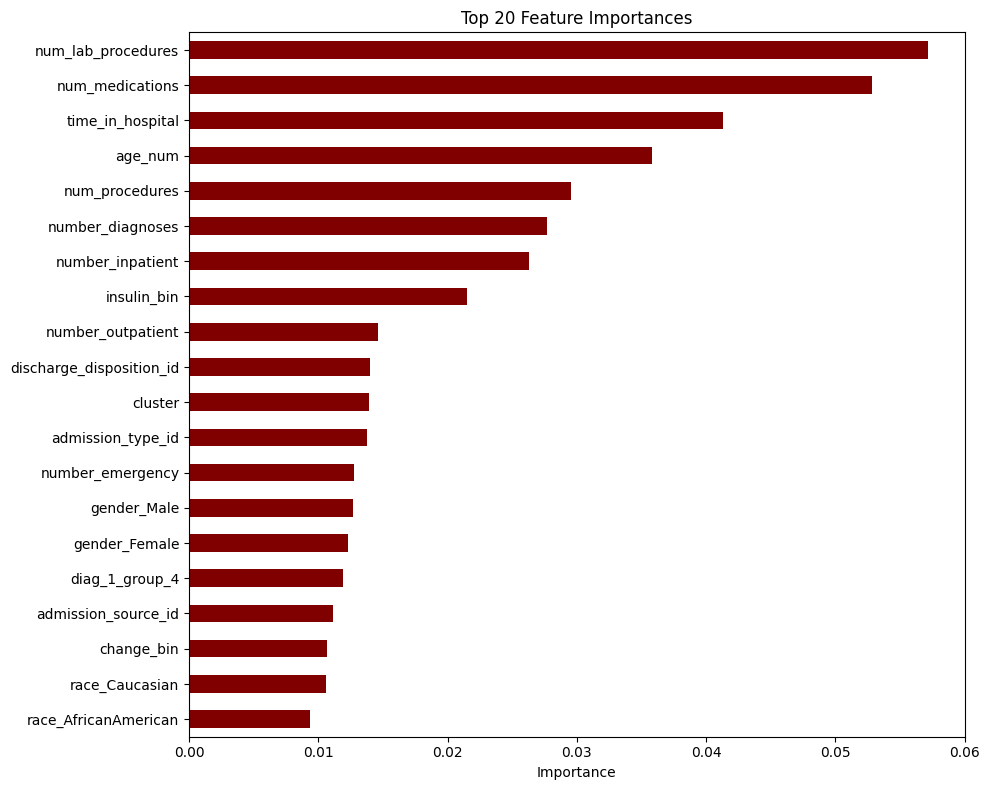

In [ ]:
# ==========================================
# [7.4] Feature Importance
# ==========================================

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(10,8))
importances.tail(20).plot(kind="barh", color="maroon")
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### [7.5] Prediction Probability Distribution
This shows the confidence of predictions and helps assess model reliability.

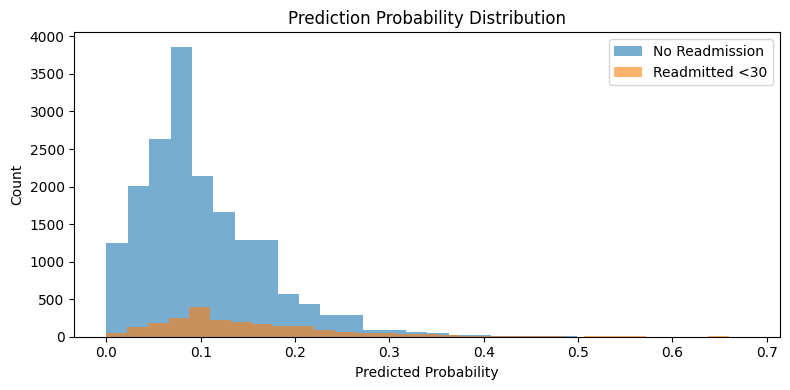

In [ ]:
# ==========================================
# [7.5] Prediction Probability Distribution
# ==========================================

plt.figure(figsize=(8,4))
plt.hist(y_proba[y_test==0], bins=30, alpha=0.6, label="No Readmission")
plt.hist(y_proba[y_test==1], bins=30, alpha=0.6, label="Readmitted <30")
plt.title("Prediction Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

### [7.6] Threshold Tuning
Adjusting thresholds allows control over precision-recall trade-offs depending on business needs.

In [ ]:
# ==========================================
# [7.6] Threshold Tuning (Optional)
# ==========================================

thresholds = np.arange(0.1, 0.9, 0.05)
for t in thresholds:
    yt = (y_proba >= t).astype(int)
    print(t, confusion_matrix(y_test, yt).ravel())

0.1 [9761 8322  711 1560]
0.15000000000000002 [14844  3239  1419   852]
0.20000000000000004 [16700  1383  1781   490]
0.25000000000000006 [17540   543  1978   293]
0.30000000000000004 [17853   230  2109   162]
0.3500000000000001 [17996    87  2183    88]
0.40000000000000013 [18052    31  2218    53]
0.45000000000000007 [18068    15  2246    25]
0.5000000000000001 [18078     5  2255    16]
0.5500000000000002 [18080     3  2262     9]
0.6000000000000002 [18082     1  2267     4]
0.6500000000000001 [18082     1  2270     1]
0.7000000000000002 [18083     0  2271     0]
0.7500000000000002 [18083     0  2271     0]
0.8000000000000002 [18083     0  2271     0]
0.8500000000000002 [18083     0  2271     0]


### [7.7] Error Analysis
Misclassified cases are analysed to identify weaknesses and potential improvements.

In [ ]:
# ==========================================
# [7.7] Error Analysis (Optional)
# ==========================================

errors = X_test.copy()
errors["actual"] = y_test
errors["pred"] = y_pred
errors["proba"] = y_proba
errors[errors["actual"] != errors["pred"]].head()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,admission_source_label_ Transfer from another health care facility,admission_source_label_ Transfer from critial access hospital,admission_source_label_ Transfer from hospital inpt/same fac reslt in a sep claim,admission_source_label_Clinic Referral,admission_source_label_HMO Referral,admission_source_label_Normal Delivery,admission_source_label_Transfer from a hospital,actual,pred,proba
13039,3,18,1,5,43,3,34,0,0,1,...,False,False,False,False,False,False,False,1,0,0.13
37502,6,22,17,12,77,6,38,0,0,0,...,False,False,False,False,False,False,False,1,0,0.25
68651,2,1,4,4,33,6,23,0,0,0,...,False,False,False,False,False,False,True,1,0,0.11
42487,2,1,7,1,9,0,5,0,1,0,...,False,False,False,False,False,False,False,1,0,0.08
29231,2,1,1,3,45,0,16,0,0,0,...,False,False,False,False,False,False,False,1,0,0.04


## Model Comparison

Models are compared using metrics such as precision, recall, and AUC.

Random Forest generally achieves higher performance due to its ability to capture complex relationships. Logistic Regression offers greater interpretability.

The final model is selected based on a balance between predictive accuracy and practical usability.

## Business Insights & Recommendations

The analysis identifies hospital utilisation and medication complexity as key drivers of readmission.

### High-Risk Patient Identification
Predictive models can identify high-risk patients prior to discharge.

### Discharge Planning Improvements
Improved discharge planning and follow-up care can reduce readmissions.

### Medication Management
Patients with complex medication regimens require additional monitoring.

### Use of Predictive Systems
Integrating predictive analytics into hospital systems can improve decision-making, optimise resources, and enhance patient outcomes.

## Limitations

### Data Limitations
The dataset is historical and based on US hospitals, limiting generalisability.

### Missing Variables
Factors such as lifestyle and socioeconomic conditions are not included.

### Model Constraints
Models simplify complex healthcare processes and should support, not replace, clinical judgement.

## Ethical, Privacy, and Security Considerations

### Bias and Fairness
Models may introduce bias across demographic groups and must be monitored for fairness.

### Data Privacy
Healthcare data is sensitive, and anonymisation does not eliminate re-identification risks.

### System Security
Strong security measures, including encryption and access control, are required to protect patient data.

Responsible use requires transparency, accountability, and ethical governance.

## Conclusion

This project demonstrates how Business Intelligence and data mining techniques can predict hospital readmissions for diabetic patients.

Key risk factors were identified, and predictive models showed strong potential for supporting healthcare decisions.

By applying these insights, hospitals can reduce readmissions, improve patient outcomes, and optimise resource allocation.

Future work could include real-time data integration and improved model interpretability.